# 🎯 Ziel dieser Lektion: Backpropagation und Optimierung

**Was wollen wir erreichen?** 
Wir lernen, wie das Netzwerk aus seinen Fehlern lernt. Der Algorithmus "Backpropagation" (Rückführung des Fehlers) ist der wichtigste Lernmechanismus in der KI.

**Von wo nach wo? (Problem & Ziel)** 
- **Ausgangssituation (Gegeben):** Das Modell macht Vorhersagen, aber diese sind noch falsch. Der Fehler (Loss) ist sehr hoch.
- **Endziel (Gesucht):** Wir wollen den tiefsten Punkt im "Fehlergebirge" finden, also die Gewichte so anpassen, dass der Fehler minimal (fast 0) wird.

### 🛤️ Ablauf (Schritt-für-Schritt)
`Vorhersage machen (Forward Pass)` ➔ `Fehler berechnen` ➔ `Fehler rückwärts durchs Netz senden (Backward Pass)` ➔ `Gradienten (Steigung) berechnen` ➔ `Gewichte durch den Optimierer verbessern`


## Exercise 1

**Dataset Used:** Custom/Synthetic Array Data (numpy)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `class AdamOptimizer:` | Definiert eine Klasse. Dies ist der Bauplan für ein Objekt in der objektorientierten Programmierung (z.B. eine eigene Netzwerkschicht). |
| `def __init__(self, lernrate=0.001, beta1=0.9, b...` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `self.lr = lernrate; self.beta1 = beta1; self.be...` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `if self.m is None:` | Eine Wenn-Dann-Bedingung. Der Code danach wird nur ausgeführt, wenn diese Bedingung wahr ist. |
| `self.m = [np.zeros_like(p) for p in params]` | Eine Schleife (Loop). Wiederholt einen bestimmten Codeblock für jedes Element in einer Liste oder für eine bestimmte Anzahl von Durchläufen (z.B. Epochen). |
| `for i, (p, g) in enumerate(zip(params, gradient...` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `return params_neu` | Gibt das berechnete Ergebnis am Ende einer Funktion zurück an den Ort, von dem die Funktion aufgerufen wurde. |
| `X_r, Y_r = np.meshgrid(x_r, y_r); Z_r = rosenbr...` | Erstellt ein 2D-Raster aus Punkten. Wird oft verwendet, um 3D-Graphen oder Konturdiagramme zu zeichnen. |
| `ax.contourf(X_r, Y_r, np.log(Z_r+1), levels=50,...` | Zeichnet ein farbig ausgefülltes Konturdiagramm (wie auf einer topografischen Landkarte, oft für Entscheidungsgrenzen). |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |
| `print(f"SGD  finale Position: {pfad_sgd[-1].rou...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |


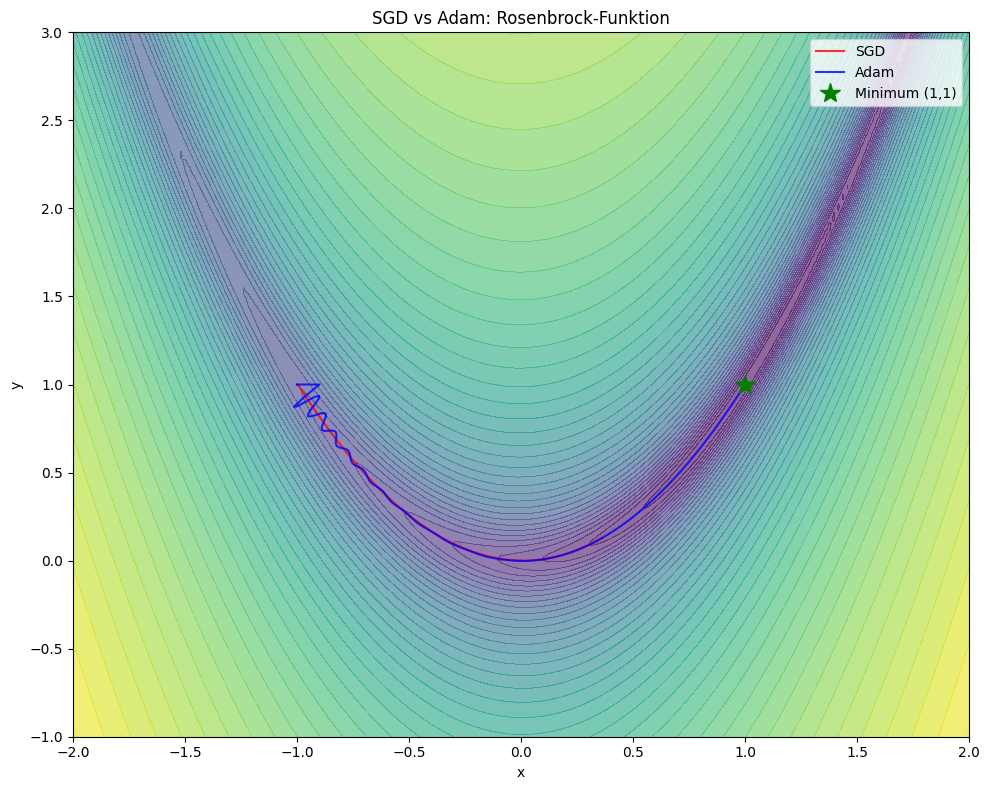

SGD  finale Position: [0.3636 0.1292], f=0.405875
Adam finale Position: [1. 1.], f=0.000000


In [1]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 5: Backpropagation & Gradientenabstieg
# Niveau: Fortgeschrittene
# Aufgabe 1 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Implement Adam optimizer from scratch
import numpy as np
import matplotlib

import matplotlib.pyplot as plt

class AdamOptimizer:
    """Adam Optimizer: Adaptive Moment Estimation (Kingma & Ba, 2015)"""
    
    def __init__(self, lernrate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.lr = lernrate; self.beta1 = beta1; self.beta2 = beta2; self.epsilon = epsilon
        self.m = None; self.v = None; self.t = 0
    
    def aktualisieren(self, params, gradienten):
        """Adam-Update für eine Liste von Parametervektoren"""
        if self.m is None:
            self.m = [np.zeros_like(p) for p in params]
            self.v = [np.zeros_like(p) for p in params]
        
        self.t += 1
        params_neu = []
        for i, (p, g) in enumerate(zip(params, gradienten)):
            # Erste und zweite Momentschätzungen
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * g**2
            # Bias-Korrektur
            m_korr = self.m[i] / (1 - self.beta1**self.t)
            v_korr = self.v[i] / (1 - self.beta2**self.t)
            # Parameter-Update
            p_neu = p - self.lr * m_korr / (np.sqrt(v_korr) + self.epsilon)
            params_neu.append(p_neu)
        return params_neu

# Rosenbrock-Funktion minimieren: f(x,y) = (1-x)^2 + 100(y-x^2)^2
def rosenbrock(x, y): return (1-x)**2 + 100*(y-x**2)**2
def rosenbrock_grad(x, y):
    dx = -2*(1-x) - 400*x*(y-x**2)
    dy = 200*(y-x**2)
    return np.array([dx, dy])

def optimiere_sgd(start=np.array([-1.0, 1.0]), schritte=1000, lr=0.001):
    """Gradient Descent Optimierung der Rosenbrock-Funktion"""
    pos = start.copy(); pfad = [pos.copy()]
    for _ in range(schritte):
        g = rosenbrock_grad(*pos)
        pos -= lr * g; pfad.append(pos.copy())
    return np.array(pfad)

def optimiere_adam(start=np.array([-1.0, 1.0]), schritte=1000, lr=0.1):
    """Adam Optimierung der Rosenbrock-Funktion"""
    adam = AdamOptimizer(lernrate=lr)
    params = [start[0:1].copy(), start[1:2].copy()]; pfad = [start.copy()]
    for _ in range(schritte):
        g = rosenbrock_grad(params[0][0], params[1][0])
        params = adam.aktualisieren(params, [g[0:1], g[1:2]])
        pfad.append(np.array([params[0][0], params[1][0]]))
    return np.array(pfad)

pfad_sgd  = optimiere_sgd()
pfad_adam = optimiere_adam()

# Rosenbrock-Landschaft visualisieren
x_r = np.linspace(-2, 2, 200); y_r = np.linspace(-1, 3, 200)
X_r, Y_r = np.meshgrid(x_r, y_r); Z_r = rosenbrock(X_r, Y_r)

fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(X_r, Y_r, np.log(Z_r+1), levels=50, cmap='viridis', alpha=0.6)
ax.plot(pfad_sgd[:,0], pfad_sgd[:,1], 'r-', linewidth=1.5, alpha=0.8, label='SGD')
ax.plot(pfad_adam[:,0], pfad_adam[:,1], 'b-', linewidth=1.5, alpha=0.8, label='Adam')
ax.plot(1, 1, 'g*', markersize=15, label='Minimum (1,1)')
ax.set_title('SGD vs Adam: Rosenbrock-Funktion')
ax.legend(); ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.savefig('adam_vs_sgd.png', dpi=100)
plt.show()
print(f"SGD  finale Position: {pfad_sgd[-1].round(4)}, f={rosenbrock(*pfad_sgd[-1]):.6f}")
print(f"Adam finale Position: {pfad_adam[-1].round(4)}, f={rosenbrock(*pfad_adam[-1]):.6f}")


## Exercise 2

**Dataset Used:** Synthetic Moons Data (sklearn.datasets)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `import tensorflow as tf` | Lädt TensorFlow, das Haupt-Framework von Google zum Erstellen und Trainieren von neuronalen Netzen. |
| `from sklearn.datasets import make_moons` | Importiert spezifische Funktionen oder Klassen aus einer anderen Bibliothek, um den Code kürzer zu machen. |
| `tf.random.set_seed(42); np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `X, y = make_moons(n_samples=800, noise=0.2, ran...` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `def erstelle_modell(optimizer):` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `tf.keras.layers.Dense(32, activation='relu', in...` | Fügt eine dicht vernetzte Schicht hinzu (Fully Connected Layer), in der jedes Neuron mit allen Neuronen der vorherigen Schicht verbunden ist. |
| `m.compile(optimizer=optimizer, loss='binary_cro...` | Setzt die binäre Kreuzentropie als Fehlerfunktion, ideal für Probleme mit nur zwei Klassen (Ja/Nein). |
| `return m` | Gibt das berechnete Ergebnis am Ende einer Funktion zurück an den Ort, von dem die Funktion aufgerufen wurde. |
| `for name in ['Konstant (0.01)', 'Exp. Abfall', ...` | Eine Schleife (Loop). Wiederholt einen bestimmten Codeblock für jedes Element in einer Liste oder für eine bestimmte Anzahl von Durchläufen (z.B. Epochen). |
| `if opt is None:` | Eine Wenn-Dann-Bedingung. Der Code danach wird nur ausgeführt, wenn diese Bedingung wahr ist. |
| `print(f"{name:25s: finale Testgenauigkeit = {h....` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |


Konstant (0.01): finale Testgenauigkeit = 97.50%


Exp. Abfall: finale Testgenauigkeit = 97.50%


Cosine: finale Testgenauigkeit = 97.50%


ReduceOnPlateau: finale Testgenauigkeit = 96.88%


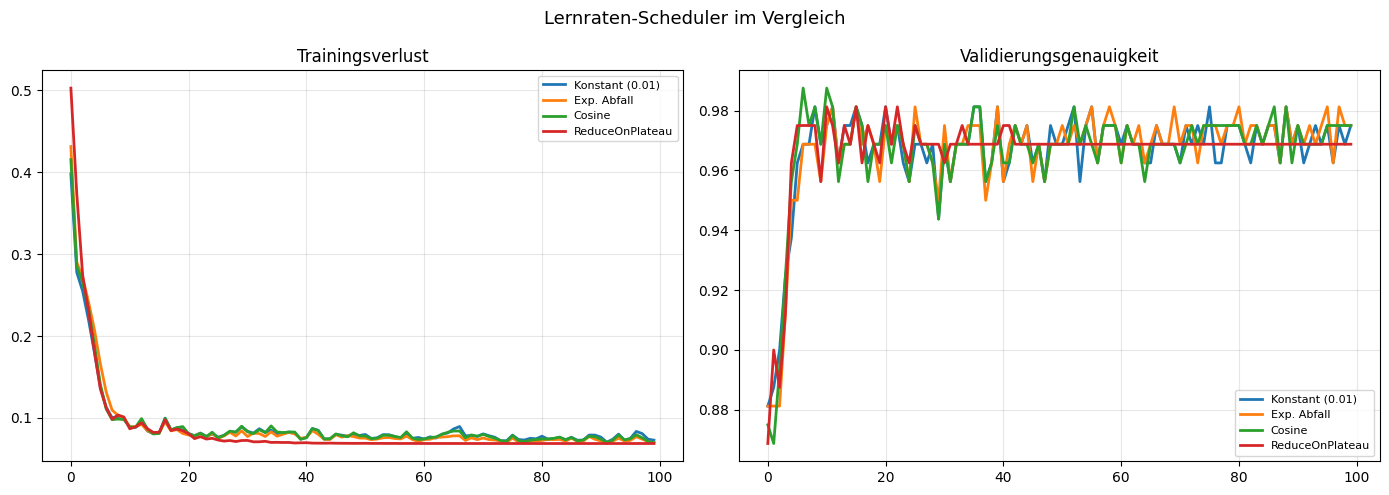

Lernraten-Scheduler gespeichert: lr_scheduler.png


In [2]:
%matplotlib inline
# ============================================================
# educx GmbH - Neuronale Netze | Modul 2
# Lerntag 5: Backpropagation & Gradientenabstieg
# Niveau: Fortgeschrittene - Aufgabe 2 von 3
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(42); np.random.seed(42)

X, y = make_moons(n_samples=800, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train); X_test = scaler.transform(X_test)

def erstelle_modell(optimizer):
    m = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation='relu', input_shape=(2,)),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    m.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return m

def get_scheduler(name):
    if name == 'Konstant (0.01)':
        return tf.keras.optimizers.Adam(0.01)
    if name == 'Exp. Abfall':
        return tf.keras.optimizers.Adam(
            tf.keras.optimizers.schedules.ExponentialDecay(0.01, 500, 0.9))
    if name == 'Cosine':
        return tf.keras.optimizers.Adam(
            tf.keras.optimizers.schedules.CosineDecay(0.01, 5000))
    if name == 'ReduceOnPlateau':
        return None

ergebnisse = {}
for name in ['Konstant (0.01)', 'Exp. Abfall', 'Cosine', 'ReduceOnPlateau']:
    tf.random.set_seed(42)
    callbacks = []
    opt = get_scheduler(name)
    if opt is None:
        opt = tf.keras.optimizers.Adam(0.01)
        callbacks.append(tf.keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5, verbose=0))
    m = erstelle_modell(opt)
    h = m.fit(X_train, y_train, epochs=100, verbose=0,
              validation_data=(X_test, y_test), callbacks=callbacks)
    ergebnisse[name] = h.history
    print(f"{name}: finale Testgenauigkeit = {h.history['val_accuracy'][-1]:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, hist in ergebnisse.items():
    axes[0].plot(hist['loss'], label=name, linewidth=2)
    axes[1].plot(hist['val_accuracy'], label=name, linewidth=2)

for ax, t in zip(axes, ['Trainingsverlust', 'Validierungsgenauigkeit']):
    ax.set_title(t); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Lernraten-Scheduler im Vergleich', fontsize=13)
plt.tight_layout()
plt.savefig('lr_scheduler.png', dpi=100)
plt.show()
print("Lernraten-Scheduler gespeichert: lr_scheduler.png")


## Exercise 3

**Dataset Used:** Custom/Synthetic Array Data (numpy)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `import tensorflow as tf` | Lädt TensorFlow, das Haupt-Framework von Google zum Erstellen und Trainieren von neuronalen Netzen. |
| `tf.random.set_seed(42); np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `X = np.random.randn(500, 10).astype(np.float32)` | Konvertiert die Daten in einen anderen Datentyp (z.B. von ganzen Zahlen in Kommazahlen wie float32, was für Keras besser ist). |
| `def erstelle_modell(gradient_clip=None):` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `m = tf.keras.Sequential([` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `tf.keras.layers.Dense(256, activation='relu', i...` | Fügt eine dicht vernetzte Schicht hinzu (Fully Connected Layer), in der jedes Neuron mit allen Neuronen der vorherigen Schicht verbunden ist. |
| `if gradient_clip:` | Eine Wenn-Dann-Bedingung. Der Code danach wird nur ausgeführt, wenn diese Bedingung wahr ist. |
| `else:` | Der Sonst-Teil einer Bedingung. Dieser Code wird ausgeführt, wenn das 'if' vorher nicht wahr war. |
| `m.compile(optimizer=opt, loss='binary_crossentr...` | Setzt die binäre Kreuzentropie als Fehlerfunktion, ideal für Probleme mit nur zwei Klassen (Ja/Nein). |
| `return m` | Gibt das berechnete Ergebnis am Ende einer Funktion zurück an den Ort, von dem die Funktion aufgerufen wurde. |
| `print(f"{name:20s}: finale Trainingsgenauigkeit...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |


Kein Clipping       : finale Trainingsgenauigkeit = 100.00%


Clip Norm 1.0       : finale Trainingsgenauigkeit = 100.00%


Clip Norm 0.1       : finale Trainingsgenauigkeit = 100.00%


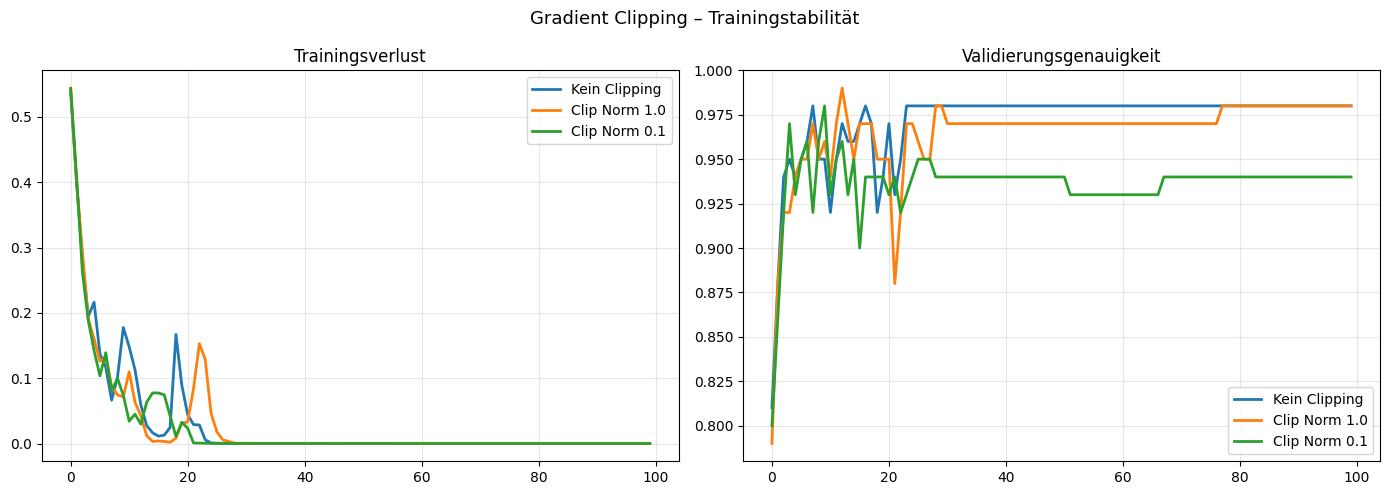

Gradient Clipping gespeichert: gradient_clipping.png
Clipping verhindert explodierende Gradienten bei instabilem Training!


In [3]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 5: Backpropagation & Gradientenabstieg
# Niveau: Fortgeschrittene
# Aufgabe 3 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Demonstrate gradient clipping for training stability
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
import tensorflow as tf

tf.random.set_seed(42); np.random.seed(42)

# Synthetische Daten mit komplexerer Struktur
X = np.random.randn(500, 10).astype(np.float32)
y = (np.sin(X[:,0]) + np.cos(X[:,1]) > 0).astype(np.float32)

def erstelle_modell(gradient_clip=None):
    """Tiefes Netz mit optionalem Gradient Clipping"""
    m = tf.keras.Sequential([
        tf.keras.layers.Dense(256, activation='relu', input_shape=(10,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    if gradient_clip:
        # clipnorm beschränkt die L2-Norm der Gradienten
        opt = tf.keras.optimizers.Adam(0.01, clipnorm=gradient_clip)
    else:
        opt = tf.keras.optimizers.Adam(0.01)
    m.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return m

ergebnisse = {}
konfigurationen = {
    'Kein Clipping': None,
    'Clip Norm 1.0':  1.0,
    'Clip Norm 0.1':  0.1
}

for name, clip in konfigurationen.items():
    tf.random.set_seed(42)
    m = erstelle_modell(clip)
    h = m.fit(X, y, epochs=100, verbose=0, validation_split=0.2)
    ergebnisse[name] = h.history
    print(f"{name:20s}: finale Trainingsgenauigkeit = {h.history['accuracy'][-1]:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, hist in ergebnisse.items():
    axes[0].plot(hist['loss'], label=name, linewidth=2)
    axes[1].plot(hist['val_accuracy'], label=name, linewidth=2)

for ax, t in zip(axes, ['Trainingsverlust', 'Validierungsgenauigkeit']):
    ax.set_title(t); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Gradient Clipping – Trainingstabilität', fontsize=13)
plt.tight_layout()
plt.savefig('gradient_clipping.png', dpi=100)
plt.show()
print("Gradient Clipping gespeichert: gradient_clipping.png")
print("Clipping verhindert explodierende Gradienten bei instabilem Training!")
